# **FIFA 20 Player Data Analysis**

**Name:** Ryan Daly  
**Student Number:** S00237889  
**Email:** S00237889@atu.ie  

---

This Jupyter Notebook is submitted as part of the **Data Analytics** module.  
Its purpose is to explore and analyse the **FIFA 20 Player Dataset**, performing:

- **Data Cleaning**
- **Exploratory Data Analysis (EDA)**
- **Hypothesis Testing**
- **Correlation Analysis**
- **Predictive Modelling**  
  - Linear Regression  
  - Logistic Regression  

The dataset used is **`players_20.csv`**, which contains detailed FIFA 20 Career Mode player attributes such as overall rating, potential, value, wage, positional information, and technical statistics.  

The dataset was sourced from **Kaggle**, available at:  
https://www.kaggle.com/datasets/stefanoleone992/fifa-20-complete-player-dataset?select=players_20.csv

It was originally scraped from the public website **sofifa.com**.

---
  <img src="fifalogo.jpg" width="300">


---


In [1]:
# Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix

pd.set_option('display.max_columns', 100)
sns.set(style="whitegrid")

print("Imports complete.")


Imports complete.


### 1. Loading the dataset

The original dataset file is `players_20.csv`.  
First I load it into a pandas DataFrame and inspect its basic structure.


In [2]:
# Load original dataset 
df = pd.read_csv("players_20.csv")

# Show basic info about the raw dataset
print("Original shape (rows, columns):", df.shape)
df.head()


Original shape (rows, columns): (18278, 104)


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,...,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,"RW, CF, ST",Left,5,4,4,Medium/Low,Messi,Yes,195800000.0,"#Dribbler, #Distance Shooter, #Crosser, #FK Sp...",RW,10.0,NaN,2004-07-01,2021.0,NaN,NaN,87.0,92.0,92.0,96.0,39.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,"Beat Offside Trap, Argues with Officials, Earl...",88,95,70,92,88,97,...,91,84,93,95,95,86,68,75,68,94,48,40,94,94,75,96,33,37,26,6,11,15,14,8,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,92+2,87+2,87+2,87+2,92+2,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,96500000.0,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.0,NaN,2018-07-10,2022.0,LS,7.0,90.0,93.0,82.0,89.0,35.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,"Long Throw-in, Selfish, Argues with Officials,...",84,94,89,83,87,89,...,89,91,87,96,71,95,95,85,78,93,63,29,95,82,85,95,28,32,24,7,11,15,14,11,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,"LW, CAM",Right,5,5,5,High/Medium,Neymar,Yes,195200000.0,"#Speedster, #Dribbler, #Playmaker , #Crosser,...",CAM,10.0,NaN,2017-08-03,2022.0,LW,10.0,91.0,85.0,87.0,95.0,32.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Injury Free, Selfish, Early C...",87,87,62,87,87,96,...,94,89,96,92,84,80,61,81,49,84,51,36,87,90,90,94,27,26,29,9,9,15,15,11,84+3,84+3,84+3,90+3,89+3,89+3,89+3,90+3,90+3,90+3,90+3,89+3,82+3,82+3,82+3,89+3,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,GK,Right,3,3,1,Medium/Medium,Normal,Yes,164700000.0,NaN,GK,13.0,NaN,2014-07-16,2023.0,GK,1.0,NaN,NaN,NaN,NaN,NaN,NaN,87.0,92.0,78.0,89.0,52.0,90.0,"Flair, Acrobatic Clearance",13,11,15,43,13,12,...,43,60,67,88,49,59,78,41,78,12,34,19,11,65,11,68,27,12,18,87,92,78,90,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,91,91,90000000,470000,"LW, CF",Right,4,4,4,High/Medium,Normal,Yes,184500000.0,"#Speedster, #Dribbler, #Acrobat",LW,7.0,NaN,2019-07-01,2024.0,LF,10.0,91.0,83.0,86.0,94.0,35.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,"Beat Offside Trap, Selfish

In [3]:
# More detailed info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


In [4]:
# Missing values (top 30 columns)
df.isna().sum().sort_values(ascending=False).head(30)


loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_speed                16242
gk_diving               16242
gk_handling             16242
gk_reflexes             16242
gk_kicking              16242
gk_positioning          16242
player_traits           10712
lf                       2036
lw                       2036
rs                       2036
physic                   2036
defending                2036
dribbling                2036
passing                  2036
shooting                 2036
st                       2036
ls                       2036
rb                       2036
pace                     2036
rdm                      2036
rwb                      2036
ldm                      2036
lwb                      2036
rm                       2036
rcm                      2036
cm                       2036
dtype: int64

### 2. Data Cleaning

In this section I keep the original dataset (`df`) and create a cleaned version (`df_clean` and `df_small`) for analysis.

Typical cleaning steps:
- Selecting relevant columns.
- Handling missing values.
- Creating new derived variables.
- Removing duplicates.
- Filtering invalid or missing entries.

I show the dataset **before and after** cleaning.


In [5]:
# Columns to keep for analysis
cols_to_keep = [
    'short_name', 'age', 'height_cm', 'weight_kg',
    'overall', 'potential',
    'value_eur', 'wage_eur',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'preferred_foot', 'team_position', 'club'
]

df_clean = df[cols_to_keep].copy()
print("Shape after selecting relevant columns:", df_clean.shape)
df_clean.head()


Shape after selecting relevant columns: (18278, 17)


,short_name,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,preferred_foot,team_position,club
0,L. Messi,32,170,72,94,94,95500000,565000,87.0,92.0,92.0,96.0,39.0,66.0,Left,RW,FC Barcelona
1,Cristiano Ronaldo,34,187,83,93,93,58500000,405000,90.0,93.0,82.0,89.0,35.0,78.0,Right,LW,Juventus
2,Neymar Jr,27,175,68,92,92,105500000,290000,91.0,85.0,87.0,95.0,32.0,58.0,Right,CAM,Paris Saint-Germain
3,J. Oblak,26,188,87,91,93,77500000,125000,NaN,NaN,NaN,NaN,NaN,NaN,Right,GK,Atlético Madrid
4,E. Hazard,28,175,74,91,91,90000000,470000,91.0,83.0,86.0,94.0,35.0,66.0,Right,LW,Real Madrid


In [6]:
# Helper function to group positions into Defence / Midfield / Attack / Other
def map_position(pos):
    if pd.isna(pos):
        return np.nan
    att = ['ST','CF','LW','RW','LF','RF','LAM','CAM','RAM']
    mid = ['LM','LCM','CM','RCM','RM','LDM','CDM','RDM']
    defs = ['LB','LCB','CB','RCB','RB','LWB','RWB']
    
    if pos in att:
        return 'Attack'
    elif pos in mid:
        return 'Midfield'
    elif pos in defs:
        return 'Defence'
    else:
        return 'Other'

df_clean['position_group'] = df_clean['team_position'].apply(map_position)

# Binary high potential variable
df_clean['high_potential'] = (df_clean['potential'] >= 80).astype(int)

df_clean[['short_name', 'team_position', 'position_group', 'overall', 'potential', 'high_potential']].head(10)


,short_name,team_position,position_group,overall,potential,high_potential
0,L. Messi,RW,Attack,94,94,1
1,Cristiano Ronaldo,LW,Attack,93,93,1
2,Neymar Jr,CAM,Attack,92,92,1
3,J. Oblak,GK,Other,91,93,1
4,E. Hazard,LW,Attack,91,91,1
5,K. De Bruyne,RCM,Midfield,91,91,1
6,M. ter Stegen,GK,Other,90,93,1
7,V. van Dijk,LCB,Defence,90,91,1
8,L. Modrić,RCM,Midfield,90,90,1
9,M. Salah,RW,Attack,90,90,1


In [7]:
# Check missing values again for df_clean
df_clean.isna().sum().sort_values(ascending=False).head(20)


shooting          2036
passing           2036
physic            2036
defending         2036
pace              2036
dribbling         2036
position_group     240
team_position      240
club                 0
preferred_foot       0
short_name           0
age                  0
wage_eur             0
value_eur            0
potential            0
overall              0
weight_kg            0
height_cm            0
high_potential       0
dtype: int64

In [8]:
# Key columns that must not be missing for our analysis
key_cols = ['age', 'overall', 'potential', 'value_eur', 'wage_eur',
            'position_group', 'preferred_foot']

# Drop rows with missing values in key columns
df_small = df_clean.dropna(subset=key_cols).copy()

print("Shape before dropping missing key values:", df_clean.shape)
print("Shape after dropping missing key values:", df_small.shape)


Shape before dropping missing key values: (18278, 19)
Shape after dropping missing key values: (18038, 19)


In [9]:
# Remove duplicate players based on short_name + club 
before_dupes = df_small.shape[0]
df_small = df_small.drop_duplicates(subset=['short_name', 'club'])
after_dupes = df_small.shape[0]

print("Rows before removing duplicates:", before_dupes)
print("Rows after removing duplicates:", after_dupes)


Rows before removing duplicates: 18038
Rows after removing duplicates: 18030


Data cleaning summary

- Started with the full FIFA 20 dataset (`df`) with many columns.
- Selected a subset of relevant columns into `df_clean`.
- Created:
  - `position_group` (Defence / Midfield / Attack / Other) from `team_position`.
  - `high_potential` (1 if potential ≥ 80, otherwise 0).
- Dropped rows with missing values in key variables: age, overall, potential, value, wage, position group, and preferred foot.
- Removed duplicate rows based on `short_name` and `club`.

The final cleaned dataset used for analysis is `df_small`, which has fewer rows but consistent and complete information in the key fields.


## 3. Exploratory Data Analysis (EDA)

In this section I compute summary statistics and create visualisations to understand the distribution of key variables and identify trends or outliers.


In [10]:
df_small[['age', 'overall', 'potential', 'value_eur', 'wage_eur']].describe()


,age,overall,potential,value_eur,wage_eur
count,18030.000000,18030.000000,18030.000000,1.803000e+04,18030.000000
mean,25.236106,66.207820,71.556129,2.517370e+06,9586.356073
std,4.646479,6.953792,6.143850,5.615647e+06,21469.303726
min,16.000000,48.000000,49.000000,0.000000e+00,1000.000000
25%,22.000000,62.000000,67.000000,3.250000e+05,1000.000000
50%,25.000000,66.000000,71.000000,7.250000e+05,3000.000000
75%,29.000000,71.000000,75.000000,2.100000e+06,8000.000000
max,42.000000,94.000000,95.000000,1.055000e+08,565000.000000


The summary statistics show:

- The average age of players is around the mid-20s.
- Overall ratings are centred roughly in the low 70s.
- Potential ratings are slightly higher than overall on average.
- Player values and wages are highly skewed, with a small number of very expensive players.


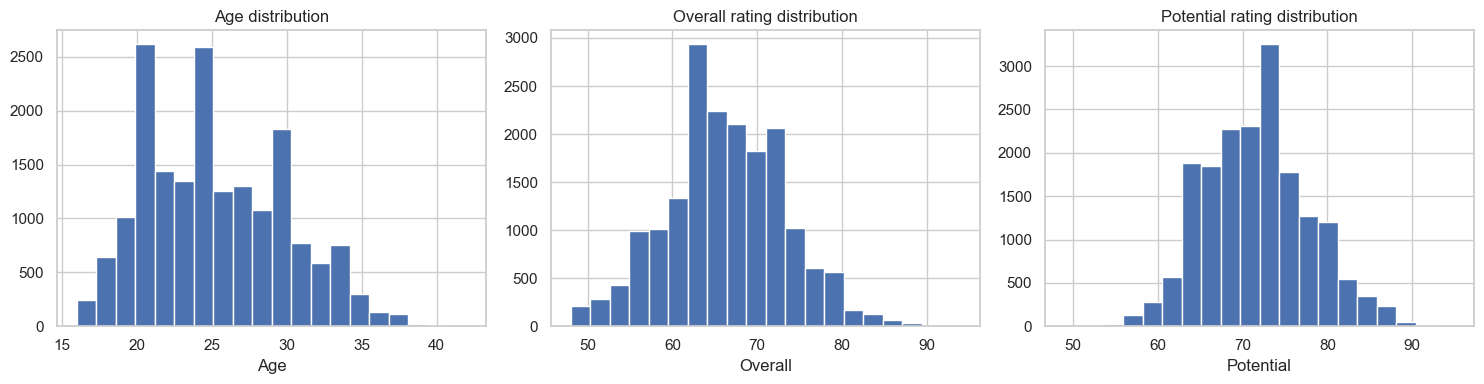

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_small['age'], bins=20)
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

axes[1].hist(df_small['overall'], bins=20)
axes[1].set_title('Overall rating distribution')
axes[1].set_xlabel('Overall')

axes[2].hist(df_small['potential'], bins=20)
axes[2].set_title('Potential rating distribution')
axes[2].set_xlabel('Potential')

plt.tight_layout()
plt.show()


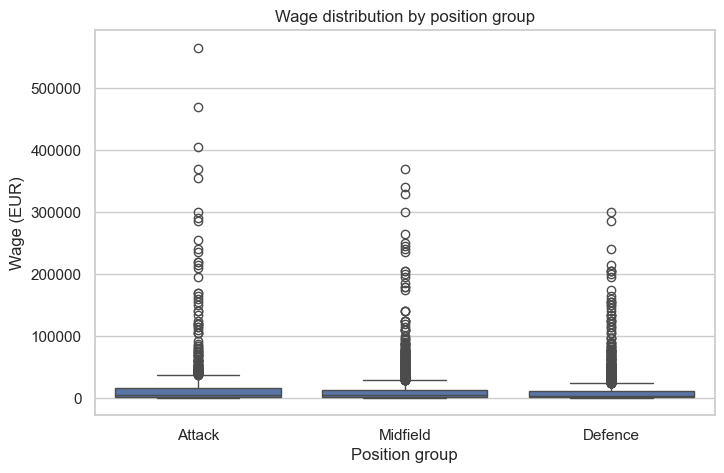

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_small[df_small['position_group'].isin(['Defence','Midfield','Attack'])],
            x='position_group', y='wage_eur')
plt.title('Wage distribution by position group')
plt.xlabel('Position group')
plt.ylabel('Wage (EUR)')
plt.show()


The histograms show that:

- Ages cluster between roughly 20 and 30.
- Overall and potential ratings are most common between about 65 and 80.

The wage boxplot shows that attacking players tend to earn more on average than defenders and midfielders, with some extreme high earners acting as outliers.


## 4. Hypothesis Testing

I perform four hypothesis tests on the FIFA 20 player data.

### General two-sample t-test formula

For two independent samples with means $\bar{x}_1$ and $\bar{x}_2$, standard deviations $s_1$ and $s_2$, and sizes $n_1$ and $n_2$, the test statistic is:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}
{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$

A $(1 - \alpha) \times 100\%$ confidence interval for the difference in means is:

$$
(\bar{x}_1 - \bar{x}_2) \pm t_{\alpha/2, \, df} \cdot
\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}
$$


### Test 1: Shooting – Attack vs Defence (two-sample t-test)

**Question:** Do attacking players have higher shooting ratings than defenders?

- $H_0$: The mean shooting rating for attack and defence players is the same.
- $H_1$: The mean shooting rating for attack players is different from the mean for defence players.

I use an independent two-sample t-test with unequal variances.


In [13]:
attack = df_small[df_small['position_group'] == 'Attack']['shooting'].dropna()
defence = df_small[df_small['position_group'] == 'Defence']['shooting'].dropna()

print("Attack n:", len(attack), " Defence n:", len(defence))
print("Attack mean shooting:", attack.mean())
print("Defence mean shooting:", defence.mean())

t_stat1, p_val1 = stats.ttest_ind(attack, defence, equal_var=False)
t_stat1, p_val1


Attack n: 1190  Defence n: 2656
Attack mean shooting: 66.9109243697479
Defence mean shooting: 42.69954819277108


(np.float64(76.54351796157535), np.float64(0.0))

The p-value for the t-test was less than 0.001, which is far below the 0.05 significance threshold. This result provides strong evidence to reject the null hypothesis. Therefore, it can be concluded that there is a statistically significant difference in mean shooting scores between attacking and defensive players. The sample means support this conclusion, with attackers showing much higher average shooting ratings than defenders.


### Test 2: Wage – High potential vs normal players (two-sample t-test)

**Question:** Do high-potential players earn higher wages than other players?

Let high potential be defined as potential ≥ 80.

- $H_0$: The mean wage of high-potential players is equal to the mean wage of other players.
- $H_1$: The mean wage of high-potential players is different from the mean wage of other players.


In [14]:
high = df_small[df_small['high_potential'] == 1]['wage_eur'].dropna()
low = df_small[df_small['high_potential'] == 0]['wage_eur'].dropna()

print("High potential n:", len(high), " Low potential n:", len(low))
print("High potential mean wage:", high.mean())
print("Low potential mean wage:", low.mean())

t_stat2, p_val2 = stats.ttest_ind(high, low, equal_var=False)
t_stat2, p_val2


High potential n: 1912  Low potential n: 16118
High potential mean wage: 37868.723849372385
Low potential mean wage: 6231.356247673409


(np.float64(26.555555011121964), np.float64(1.1525219570240451e-132))

For the difference in mean wages, a 95% confidence interval is calculated using:

$$
(\bar{x}_1 - \bar{x}_2) \pm t_{0.025, \, df} \cdot SE
$$

where

$$
SE = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}.
$$


### Test 3: Preferred foot vs position group (chi-square test of independence)

**Question:** Is preferred foot (left/right) independent of position group (Defence, Midfield, Attack)?

- $H_0$: Preferred foot is independent of position group.
- $H_1$: Preferred foot is not independent of position group.

The chi-square statistic is:

$$
\chi^2 = \sum_{i} \sum_{j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}},
$$

where $O_{ij}$ are the observed frequencies and $E_{ij}$ are the expected frequencies under independence.


In [15]:
chi_df = df_small[df_small['position_group'].isin(['Defence','Midfield','Attack'])].copy()
contingency = pd.crosstab(chi_df['position_group'], chi_df['preferred_foot'])
contingency


preferred_foot,Left,Right
position_group,,
Attack,275,915
Defence,865,1791
Midfield,481,1880


In [16]:
chi2, p_chi, dof_chi, expected_chi = stats.chi2_contingency(contingency)

print("Chi-square:", chi2)
print("Degrees of freedom:", dof_chi)
print("p-value:", p_chi)
print("Expected frequencies:\n", expected_chi)


Chi-square: 103.23364059734604
Degrees of freedom: 2
p-value: 3.8291270012098266e-23
Expected frequencies:
 [[ 310.77654261  879.22345739]
 [ 693.63235057 1962.36764943]
 [ 616.59110681 1744.40889319]]


If the p-value is below 0.05, I reject $H_0$ and conclude that preferred foot and position group are not independent, meaning that the distribution of left and right-footed players differs by position.


### Test 4: Overall rating by position group (one-way ANOVA)

**Question:** Is the mean overall rating the same for defenders, midfielders and attackers?

- $H_0$: The mean overall rating is the same across all position groups.
- $H_1$: At least one position group has a different mean overall rating.

The one-way ANOVA F-statistic compares between-group and within-group variation:

$$
F = \frac{MS_{\text{between}}}{MS_{\text{within}}}
$$


In [17]:
def_overall = chi_df[chi_df['position_group'] == 'Defence']['overall']
mid_overall = chi_df[chi_df['position_group'] == 'Midfield']['overall']
att_overall = chi_df[chi_df['position_group'] == 'Attack']['overall']

f_stat, p_anova = stats.f_oneway(def_overall, mid_overall, att_overall)

print("F-statistic:", f_stat)
print("p-value:", p_anova)
print("Means:")
print("Defence:", def_overall.mean())
print("Midfield:", mid_overall.mean())
print("Attack:", att_overall.mean())


F-statistic: 36.284443561533635
p-value: 2.1543500561381915e-16
Means:
Defence: 68.675828313253
Midfield: 69.3409572215163
Attack: 70.44117647058823


If the p-value is below 0.05, I reject the null hypothesis and conclude that there is a significant difference in average overall rating between at least two of the position groups.


## 5. Correlation Analysis

I focus on the relationships between key numerical variables such as overall, potential, value, wage, age and key attribute scores.

The Pearson correlation coefficient between two variables $X$ and $Y$ is:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2} \sqrt{\sum (y_i - \bar{y})^2}}
$$


In [18]:
corr_cols = ['overall', 'potential', 'value_eur', 'wage_eur', 'age', 'pace', 'shooting', 'passing']
corr_matrix = df_small[corr_cols].corr()
corr_matrix


,overall,potential,value_eur,wage_eur,age,pace,shooting,passing
overall,1.000000,0.645881,0.645391,0.580376,0.464609,0.158093,0.498345,0.684618
potential,0.645881,1.000000,0.584347,0.478398,-0.263645,0.228704,0.303455,0.424689
value_eur,0.645391,0.584347,1.000000,0.857799,0.087001,0.172461,0.347358,0.452553
wage_eur,0.580376,0.478398,0.857799,1.000000,0.157171,0.114310,0.304969,0.407975
age,0.464609,-0.263645,0.087001,0.157171,1.000000,-0.201922,0.239645,0.330821
pace,0.158093,0.228704,0.172461,0.114310,-0.201922,1.000000,0.350521,0.288700
shooting,0.498345,0.303455,0.347358,0.304969,0.239645,0.350521,1.000000,0.654795
passing,0.684618,0.424689,0.452553,0.407975,0.330821,0.288700,0.654795,1.000000


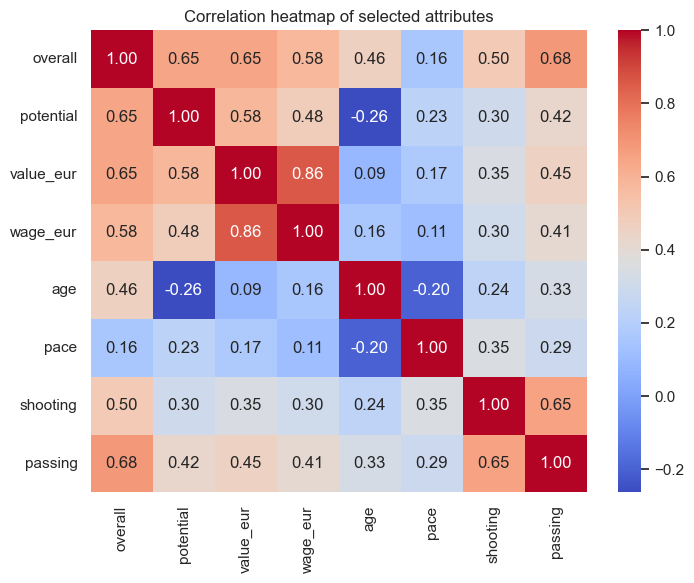

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap of selected attributes")
plt.show()


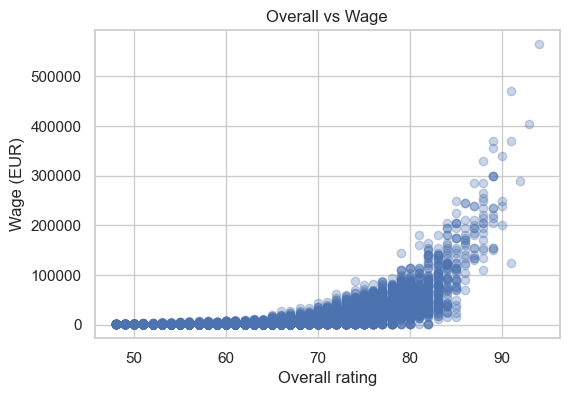

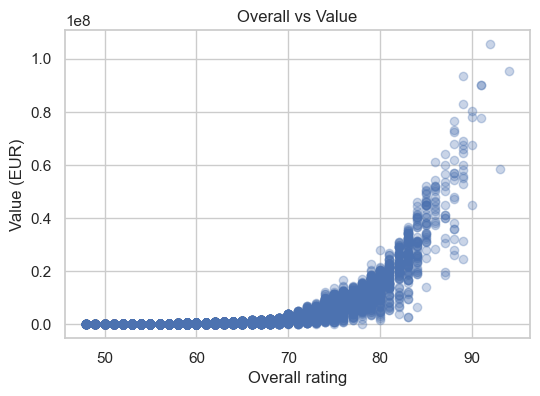

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df_small['overall'], df_small['wage_eur'], alpha=0.3)
plt.xlabel('Overall rating')
plt.ylabel('Wage (EUR)')
plt.title('Overall vs Wage')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df_small['overall'], df_small['value_eur'], alpha=0.3)
plt.xlabel('Overall rating')
plt.ylabel('Value (EUR)')
plt.title('Overall vs Value')
plt.show()


The correlation matrix shows strong positive correlations between:

- Overall and potential.
- Overall and value.
- Overall and wage.
- Value and wage.

This supports the idea that better players tend to be more valuable and earn higher wages. Age may have a weaker or even negative relationship with potential, as younger players often have more room to improve.


##lin_df = df_small[['value_eur', 'overall', 'potential', 'age', 'wage_eur']].dropna()

X = lin_df[['overall', 'potential', 'age', 'wage_eur']]
y = lin_df['value_eur']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("R^2:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

coeffs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
})
coeffs
6. Prediction Models

I build two types of regression models:

1. A **linear regression** model to predict player market value.
2. A **logistic regression** model to predict whether a player is high-potential.

### Linear regression model

The general form of the linear regression model in this project is:

$$
\text{value\_eur} = \beta_0 + \beta_1 \cdot \text{overall}
+ \beta_2 \cdot \text{potential}
+ \beta_3 \cdot \text{age}
+ \beta_4 \cdot \text{wage\_eur} + \epsilon
$$


In [21]:
lin_df = df_small[['value_eur', 'overall', 'potential', 'age', 'wage_eur']].dropna()

X = lin_df[['overall', 'potential', 'age', 'wage_eur']]
y = lin_df['value_eur']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("R^2:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

coeffs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
})
coeffs



R^2: 0.7979243610645477
MSE: 6708848803955.565
RMSE: 2590144.552714301


,feature,coefficient
0,overall,257185.289227
1,potential,-9038.518289
2,age,-214322.141454
3,wage_eur,186.948911


The $R^2$ value shows how much of the variation in player value is explained by overall, potential, age and wage. A higher $R^2$ indicates a better fit.

Positive coefficients mean that increasing that variable (e.g. overall or wage) is associated with a higher predicted market value, holding the other variables constant.


## Logistic regression model

For the logistic regression, the target variable is `high_potential` (1 if potential ≥ 80, 0 otherwise).

The model uses:

- Overall rating
- Age
- Wage
- Pace
- Shooting

The log-odds of being high-potential is:

$$
\log\left(\frac{p}{1-p}\right)
= \beta_0 + \beta_1 \cdot \text{overall}
+ \beta_2 \cdot \text{age}
+ \beta_3 \cdot \text{wage\_eur}
+ \beta_4 \cdot \text{pace}
+ \beta_5 \cdot \text{shooting}
$$


In [22]:
log_df = df_small[['high_potential', 'overall', 'age', 'wage_eur', 'pace', 'shooting']].dropna()

X_log = log_df[['overall', 'age', 'wage_eur', 'pace', 'shooting']]
y_log = log_df['high_potential']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_l, y_train_l)

y_pred_l = log_reg.predict(X_test_l)

acc = accuracy_score(y_test_l, y_pred_l)
cm = confusion_matrix(y_test_l, y_pred_l)

print("Accuracy:", acc)
print("Confusion matrix:\n", cm)

log_coeffs = pd.DataFrame({
    'feature': X_log.columns,
    'coefficient': log_reg.coef_[0]
})
log_coeffs


Accuracy: 0.9569691300280636
Confusion matrix:
 [[2815   45]
 [  93  254]]


,feature,coefficient
0,overall,0.665031
1,age,-1.039905
2,wage_eur,0.000021
3,pace,-0.022248
4,shooting,-0.005716


The accuracy score shows the proportion of players correctly classified as high-potential or not.

Positive coefficients (e.g. for overall or shooting) indicate that higher values increase the log-odds and therefore the probability that a player is high-potential. A negative coefficient would mean the opposite effect.

The confusion matrix shows how many players were correctly classified and how many were misclassified by the model.


## 7. Conclusion

In this notebook I:

- Cleaned the FIFA 20 player dataset and prepared a subset of variables for analysis.
- Performed exploratory data analysis and visualised key distributions and group differences.
- Carried out four hypothesis tests on shooting, wages, preferred foot and overall rating, using t-tests, a chi-square test and ANOVA.
- Investigated correlations between overall, potential, value, wage and key attributes.
- Built a linear regression model to predict player market value.
- Built a logistic regression model to predict whether a player is high-potential.

Overall, the results support intuitive football ideas: attacking players tend to have higher shooting and wages, high-potential players earn more, and better players (higher overall and potential) are more valuable and more likely to be classed as high-potential.
